In [1]:
from disk_analyzer.research.paths import artifacts_dir
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from disk_analyzer.models import DiskDataset
from disk_analyzer.research.config import DEFAULT_TIMES as TIMES
from disk_analyzer.research.aggregation.predictions_aggregator import PredictionsAggregator
import pickle

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

EXP_NUM = 141
RES_FOLDER = str(artifacts_dir(EXP_NUM))
MODELS_FOLDER = os.path.join(RES_FOLDER, "models")
BATCH_SIZE = 1024
DATA_EXT = 'csv'
DATA = f'Data/Preprocessed_old/20_train_preprocessed.{DATA_EXT}'

/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/survivors/metrics.py:113: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def get_before(estim, wei):
/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/survivors/metrics.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argu

In [2]:
with open(os.path.join(MODELS_FOLDER, '2_CoxTV.pkl'), 'rb') as f:
    model = pickle.load(f)

In [3]:
model.print_summary()

/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/lifelines/utils/printer.py:62: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return summary_df[columns].to_latex(float_format="%." + str(self.decimals) + "f")


<lifelines.CoxTimeVaryingEstimator: fitted with 197985 periods, 10037 subjects, 7625 events>
         event col = 'failure'
         penalizer = 0.1
number of subjects = 10037
 number of periods = 197985
  number of events = 7625
partial log-likelihood = -64716.86
  time fit was run = 2026-04-11 14:07:53 UTC

---
                 coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                              
smart_5_raw      0.11       1.11       0.01             0.10             0.12                 1.10                 1.13
smart_197_raw    0.03       1.03       0.01             0.02             0.04                 1.02                 1.04
smart_194_raw    0.01       1.01       0.01             0.00             0.03                 1.00                 1.03
smart_184_raw    0.02       1.02       0.01             0.01             0.03                 1.01                 1.03
smart_193_raw    0.01       1.01       0.00             0.00             0.02                 1.00                 1.02
smart_4_raw     -0.00       1.00       0.01            -0.01             0.01                 0.99                 1.01
capacity_bytes   0.02       1.02       0.01             0.00             0.03                 1.00                 1.03
smart_198_raw    0.01       1.01       0.01             0.00             0.02                 1.00                 1.02
smart_183_raw    0.01       1.01       0.01            -0.00             0.02                 1.00                 1.02
smart_8_raw     -0.08       0.92       0.01            -0.09            -0.07                 0.91                 0.93
smart_240_raw   -0.01       0.99       0.01            -0.02             0.01                 0.98                 1.01
smart_196_raw    0.04       1.04       0.01             0.03             0.05                 1.03                 1.05
smart_192_raw    0.00       1.00       0.01            -0.01             0.02                 0.99                 1.02
smart_10_raw     0.02       1.02       0.00             0.01             0.03                 1.01                 1.03
smart_190_raw    0.07       1.07       0.01             0.05             0.08                 1.05                 1.08
smart_242_raw    0.08       1.08       0.01             0.06             0.09                 1.06                 1.09
smart_9_raw      0.05       1.05       0.01             0.04             0.06                 1.04                 1.06
smart_3_raw     -0.01       0.99       0.01            -0.03            -0.00                 0.98                 1.00
smart_187_raw    0.02       1.02       0.01             0.00             0.03                 1.00                 1.03
smart_7_raw      0.01       1.01       0.00            -0.00             0.01                 1.00                 1.01
smart_189_raw    0.01       1.01       0.01            -0.00             0.02                 1.00                 1.02
smart_199_raw    0.01       1.01       0.01            -0.00             0.02                 1.00                 1.02
smart_1_raw      0.01       1.01       0.00             0.01             0.02                 1.01                 1.02
smart_12_raw     0.02       1.02       0.01             0.01             0.03                 1.01                 1.03
smart_191_raw    0.01       1.01       0.01             0.00             0.02                 1.00                 1.02
smart_188_raw    0.01       1.01       0.01             0.00             0.02                 1.00                 1.02
smart_2_raw     -0.08       0.92       0.01            -0.09            -0.07                 0.91                 0.94
smart_195_raw   -0.00       1.00       0.01            -0.01             0.01                 0.99                 1.01
smart_241_raw    0.02       1.02       0.01             0.00             0.03        

In [3]:
dl = DataLoader(dataset = DiskDataset('score', [DATA]),
        batch_size = BATCH_SIZE)

In [4]:
df_test = pd.read_csv(DATA) if DATA_EXT == 'csv' else pd.read_parquet(DATA) 
df_test = df_test[df_test['time'] != df_test['max_lifetime']]

In [5]:
AGG_MODE = 't_dist'
AGG_WEIGHT = 0.1
pred_agg = PredictionsAggregator(mode=AGG_MODE, weight=AGG_WEIGHT)
extended_times = pred_agg.get_extended_times(df_test, times = TIMES)
X_pred, X_gt = model.predict(dl, times=TIMES)

In [6]:
def plot_agg_grid(X_pred, X_gt, serial_nums, times, agg_tuples, agg_observ):
    '''
    X_pred - датафрейм с предсказанными функциями выживания
    X_gt - датафрейм с временем жизни и флагом цензурирования
    serial_nums - список из 4 серийных номеров
    times - временная шкала
    agg_tuples - список кортежей (agg_mode, weight, n_agg)
    agg_observ - порядковый номер наблюдения к которому агрегируемся
    '''
    _, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.ravel()
    
    for i, serial_num in enumerate(serial_nums):
        X_trunc = X_pred[X_pred['serial_number'] == serial_num]
        X_gt_trunc = X_gt[X_gt['serial_number'] == serial_num]
        event = X_gt_trunc.iloc[agg_observ, -1]
        duration = X_gt_trunc.iloc[agg_observ, -2]
        
        for (agg_mode, weight, n_agg) in agg_tuples:
            X_cur_pred = X_trunc.head(agg_observ).tail(n_agg)
            pred_agg = PredictionsAggregator(mode=agg_mode, weight=weight)
            cur_timeshift = X_cur_pred.groupby('serial_number')['time'].transform('max') - X_cur_pred['time']
            pred = pred_agg.predict(X_cur_pred, times=times, timeshift=cur_timeshift)
            
            label = f"{agg_mode} (w={weight}, n={n_agg})"
            sns.lineplot(x=times, 
                        y=pred.drop(columns=['serial_number', 'time']).iloc[0], 
                        label=label,
                        linewidth=2,
                        ax=axes[i])
        
        event_color = 'r' if event else 'b'
        axes[i].axvline(x=duration, color=event_color, linestyle='--', linewidth=2)
        axes[i].set_title(f'Device {serial_num}', fontsize=12)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
        axes[i].get_legend().remove()
    
    plt.tight_layout()
    plt.show()

In [7]:
X_pred[X_gt['failure'] == 0][X_pred[X_gt['failure'] == 0][20] > 0.9]

,serial_number,time,0,1,2,3,4,5,6,7,...,2085,2086,2087,2088,2089,2090,2091,2092,2093,2094
0,0F112CC45,467,0.998278,0.998278,0.996676,0.995031,0.993458,0.992038,0.990688,0.989099,...,0.437373,0.437373,0.437373,0.437373,0.437373,0.437373,0.437373,0.437373,0.437373,0.437373
1,0F112CC45,468,0.998403,0.998403,0.996917,0.995390,0.993931,0.992613,0.991361,0.989886,...,0.464413,0.464413,0.464413,0.464413,0.464413,0.464413,0.464413,0.464413,0.464413,0.464413
2,0F112CC45,469,0.998265,0.998265,0.996650,0.994992,0.993408,0.991976,0.990616,0.989014,...,0.434569,0.434569,0.434569,0.434569,0.434569,0.434569,0.434569,0.434569,0.434569,0.434569
3,0F112CC45,470,0.998391,0.998391,0.996893,0.995354,0.993884,0.992556,0.991293,0.989807,...,0.461642,0.461642,0.461642,0.461642,0.461642,0.461642,0.461642,0.461642,0.461642,0.461642
4,0F112CC45,471,0.998429,0.998429,0.996968,0.995466,0.994031,0.992735,0.991502,0.990052,...,0.470326,0.470326,0.470326,0.470326,0.470326,0.470326,0.470326,0.470326,0.470326,0.470326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342336,ZCH061B8,679,0.998658,0.998658,0.997409,0.996126,0.994899,0.993790,0.992736,0.991495,...,0.524984,0.524984,0.524984,0.524984,0.524984,0.524984,0.524984,0.524984,0.524984,0.524984
342337,ZCH061B8,680,0.998676,0.998676,0.997443,0.996177,0.994967,0.993873,0.992833,0.991608,...,0.529505,0.529505,0.529505,0.529505,0.529505,0.529505,0.529505,0.529505,0.529505,0.529505
342338,ZCH061B8,681,0.998672,0.998672,0.997435,0.996165,0.994951,0.993853,0.992810,0.991581,...,0.528436,0.528436,0.528436,0.528436,0.528436,0.528436,0.528436,0.528436,0.528436,0.528436
342339,ZCH061B8,682,0.998668,0.998668,0.997427,0.996153,0.994935,0.993834,0.992787,0.991555,...,0.527366,0.527366,0.527366,0.527366,0.527366,0.527366,0.527366,0.527366,0.527366,0.527366


In [8]:
X_gt[X_gt['failure'] == False]['serial_number'].unique()

<StringArray>
['0F112CC45', '13H2B97AS', '13H32WEAS', '13H6A21GS', '13H7X2HAS', '13H85BMGS',
 '13H87YWAS', '13H89KSGS', '13H89U2GS', '13H8AB0GS',
 ...
  'ZA18BTL5',  'ZA18BTPW',  'ZA18BTR5',  'ZA18CCWM',  'ZA18CD35',  'ZA18CDDE',
  'ZCH05JXQ',  'ZCH05L1Z',  'ZCH05TTR',  'ZCH061B8']
Length: 15042, dtype: string

In [9]:
model.print_summary()

/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/lifelines/utils/printer.py:62: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return summary_df[columns].to_latex(float_format="%." + str(self.decimals) + "f")


<lifelines.CoxTimeInvariantLNFitter: fitted with 342563 total observations, 297576 right-censored observations>
             duration col = 'duration'
                event col = 'failure'
                penalizer = 1.0
                 l1 ratio = 0.1
      baseline estimation = breslow
   number of observations = 342563
number of events observed = 44987
   partial log-likelihood = -540411.93
         time fit was run = 2026-04-08 08:57:08 UTC

---
                 coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                              
capacity_bytes   0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_1_raw      0.03       1.03       0.00             0.03             0.04                 1.03                 1.04
smart_2_raw     -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_3_raw     -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_4_raw     -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_5_raw      0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_7_raw      0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_8_raw     -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_9_raw     -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_10_raw    -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_12_raw    -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_183_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_184_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_187_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_188_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_189_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_190_raw    0.06       1.06       0.00             0.06             0.06                 1.06                 1.07
smart_191_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_192_raw   -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_193_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_194_raw   -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_196_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_197_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_198_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_199_raw   -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_240_raw    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
smart_241_raw    0.05       1.05       0.00             0.05             0.05                 1.05                 1.06
smart_242_raw    0.00       1.00       0.00            -0.00      

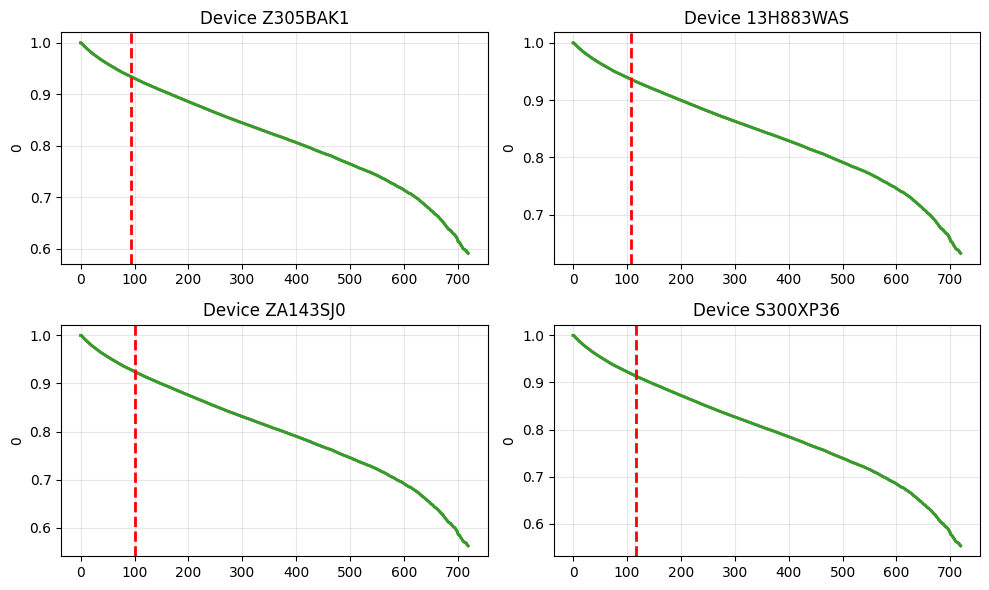

In [14]:
# disks = ['5732PE2OT', 'S300Z5WC', '13H87YWAS', 'JK1101B8JMWZSZ']
# disks = ['JK11A8B9J67Z0F', 'PL1331LAGS94VH', 'ZA143SJ0', 'S300XP36']
# disks = ['Z305BAK1', 'JK1101B9GDZJEF', 'ZA143SJ0', 'S300XP36']
disks = ['Z305BAK1', '13H883WAS', 'ZA143SJ0', 'S300XP36'] # all dead x_x
# disks = ['2EG3P72P', '2EG4LSHP', '5VY4HN76', '5XW00TCN'] # all cens

TIMES = np.arange(0, 720)
t_dist_scenarios = [('t_dist', 1, 1), ('t_dist', 0.1, 1), ('t_dist', 100, 1)]
# t_dist_scenarios = [('t_dist', 1, 2)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = t_dist_scenarios, agg_observ= 1)
# plot_agg_for_observ(X_pred, X_gt, serial_num='5732PE2OT', times = TIMES, agg_tuples = t_dist_scenarios, agg_observ= 5)

In [11]:
X_pred_alpha = X_pred.copy()
MAX_CLIP = 1
POW_SCALE = (-max(TIMES) * MAX_CLIP) / np.log(0.01)
print(f'POW_SCALE > 1/{POW_SCALE}')
X_pred_alpha.iloc[:,2:] = np.power(X_pred_alpha.iloc[:,2:], 1/10)

POW_SCALE > 1/454.7063225527047


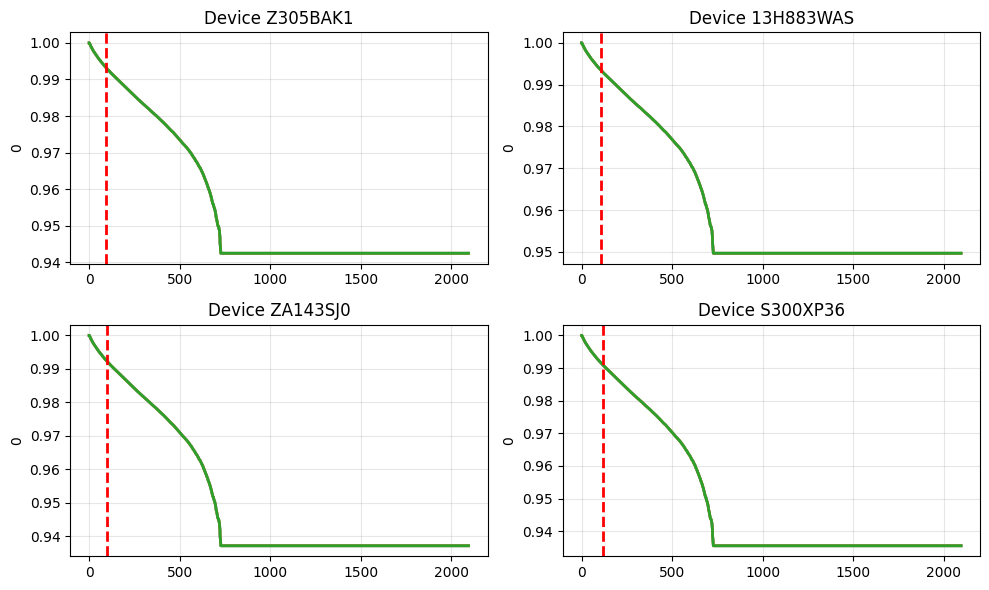

In [12]:
n_dist_scenarios = [('n_dist', 0.1, 1), ('n_dist', 0.5, 1), ('n_dist', 0.9, 1)]
plot_agg_grid(X_pred_alpha, X_gt, serial_nums = disks, times = TIMES, agg_tuples = n_dist_scenarios, agg_observ = 1)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = n_dist_scenarios, agg_observ= 5)

IndexError: index 2095 is out of bounds for axis 1 with size 2095

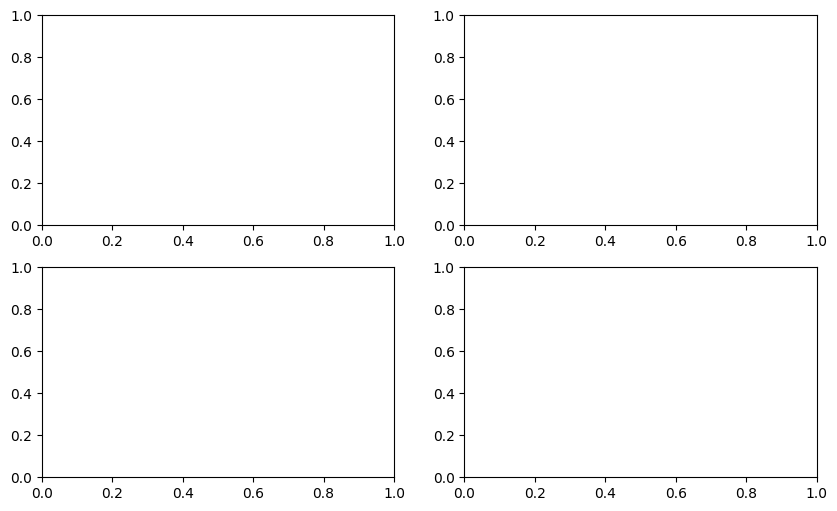

In [13]:
geom_scenarios = [('geom', 0.1, 5), ('geom', 0.5, 5), ('geom', 0.9, 5)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = geom_scenarios, agg_observ= 10)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = n_dist_scenarios, agg_observ= 5)
# 5732PE2OT
# 13H87YWAS

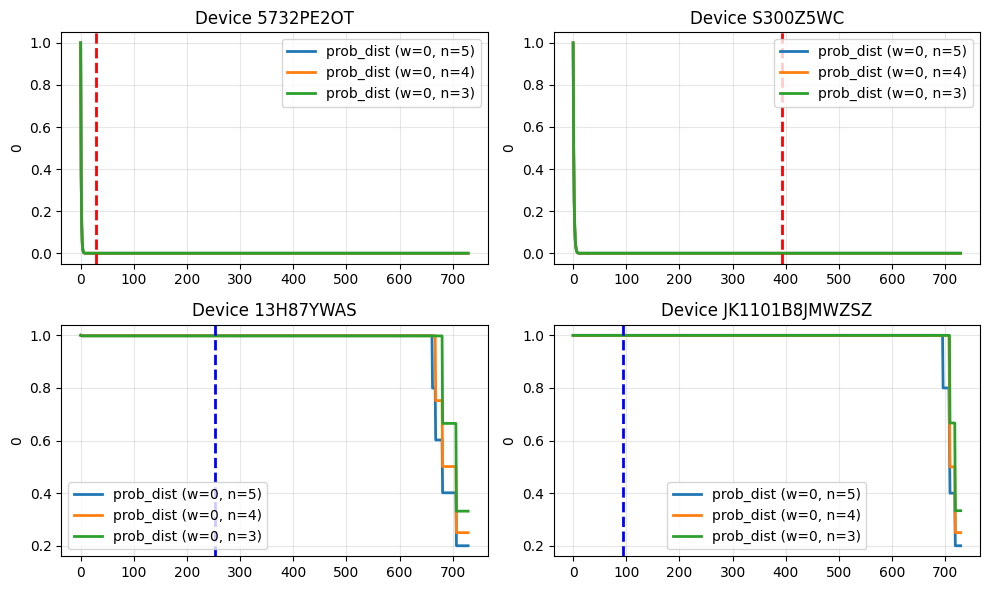

In [ ]:
prob_scenarios = [('prob_dist', 0, 5), ('prob_dist', 0, 4), ('prob_dist', 0, 3)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = prob_scenarios, agg_observ= 10)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = prob_scenarios, agg_observ= 5)
# 5732PE2OT
# 13H87YWAS

In [ ]:
only_failure = X_gt[(X_gt['failure'] == 1)]
only_failure[only_failure['time'] == only_failure.groupby('serial_number')['time'].transform('max')]


,serial_number,time,duration,failure
148,5732PE2OT,719,1,True
827,96ICTBQIT,416,1,True
852,9QM04GKZ,505,3,True
2513,JK1101B9J301EF,178,1,True
3347,JK1101B9JP60TU,8,1,True
...,...,...,...,...
106568,ZA189K7R,617,1,True
106599,ZA18BLFG,626,1,True
106624,ZA18BLNT,675,3,True
106633,ZCH04Y2W,677,1,True


In [ ]:
(X_gt[X_gt['failure'] == 1]['duration'] - X_predicted_duration).median()

112.60177783010822

In [ ]:
(X_gt[X_gt['failure'] == 1]['duration'] - X_no_agg_predict).mean()


163.160056689063

# Metriki s axis

In [ ]:
from lifelines.utils import concordance_index  # type: ignore
from survivors.metrics import ibs_remain
import pandas as pd

def bal_ibs_remain(survival_train, survival_test, estimate, times, axis=-1):
    """ IBS with equal impact of each event type and partial observation with controlled quantity """
    ibs_event = ibs_remain(survival_train, survival_test[survival_test["event"]],
                            estimate[survival_test["event"]], times, axis=axis)
    ibs_cens = ibs_remain(survival_train, survival_test[~survival_test["event"]],
                            estimate[~survival_test["event"]], times, axis=axis)
    return (ibs_event + ibs_cens)/2

def get_ci_ibs_ibs_bal(model, df_pred: pd.DataFrame, df_gt: pd.DataFrame, times: np.ndarray, axis=-1):
    """Calculate Concordance Index (CI) and Integrated Brier Score (IBS).

    Args:
        model: The trained model used for predictions.
        df_pred (pd.DataFrame): DataFrame containing predicted survival functions.
        df_gt (pd.DataFrame): DataFrame containing ground truth durations and event indicators.
        times (np.ndarray): Array of time points for evaluation.

    Returns:
        Tuple[float, float, float]: Concordance Index (CI), Integrated Brier Score (IBS) and balanced IBS.
    """
    survival_test = pd.DataFrame()
    survival_test['event'] = df_gt['failure'].astype(bool)
    survival_test['duration'] = df_gt['duration']

    lifetime_pred = model.get_expected_time_by_predictions(df_pred, times)

    ci = concordance_index(df_gt['duration'], lifetime_pred, df_gt['failure'])

    survival_estim = df_pred.drop(['serial_number', 'time'], axis='columns')
    ibs = ibs_remain(
        None,
        survival_test.to_records(index=False),
        survival_estim,
        times,
        axis=axis
    )

    ibs_bal = bal_ibs_remain(
        None,
        survival_test.to_records(index=False),
        survival_estim,
        times,
        axis=-1
    )

    return ci, ibs, ibs_bal

In [ ]:
ci_orig, ibs_orig, ibs_bal_orig = get_ci_ibs_ibs_bal(model, X_pred, X_gt, TIMES)

In [ ]:
ci_orig, ibs_orig, ibs_bal_orig

(0.8288555896768071, 0.15351459947245033, 0.1937280674273985)

In [ ]:
X_pred_alpha = X_pred.copy()
X_pred_alpha.iloc[:,2:] = np.power(X_pred_alpha.iloc[:,2:], 1/100)

In [ ]:
ci, ibs, ibs_bal = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = -1)
# _, ibs_along_time, ibs_bal_time = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = 1)
# _, ibs_along_obs, ibs_bal_obs = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = 0)


In [ ]:
ci, ibs, ibs_bal

(0.8287200037765029, 0.3685673852528441, 0.3728607962522196)

# Graphiki korrektirovki

In [ ]:
import seaborn as sns
inv_alpha_grid = [1, 10, 50, 100, 500, 1000]
df_alpha = pd.DataFrame(columns = ['inv_alpha', 'ci', 'ibs', 'ibs_bal'])
for inv_alpha in inv_alpha_grid:
    cur_X_pred_alpha = X_pred.copy()
    cur_X_pred_alpha.iloc[:,2:] = np.power(cur_X_pred_alpha.iloc[:,2:], 1/inv_alpha)
    ci, ibs, ibs_bal = get_ci_ibs_ibs_bal(model, cur_X_pred_alpha, X_gt, TIMES, axis = -1)
    df_alpha.loc[len(df_alpha)] = {"inv_alpha": inv_alpha,
                                        "ci":ci,
                                        "ibs": ibs,
                                        "ibs_bal": ibs_bal}

max_clip: 1, pow_scale: 158.3003386537353


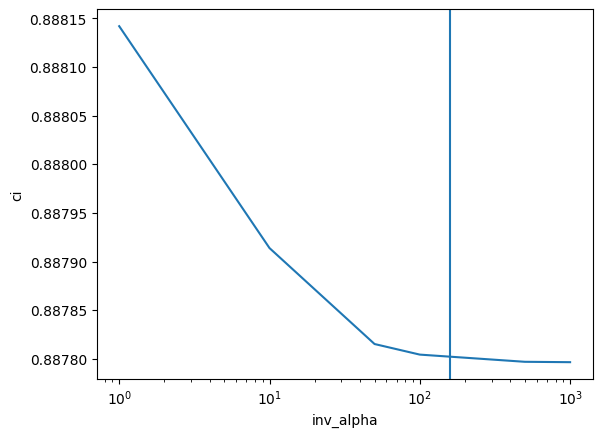

In [ ]:
ax = sns.lineplot(df_alpha, x = 'inv_alpha', y = 'ci').set(xscale='log')
plt.axvline(POW_SCALE)
print(f'max_clip: {MAX_CLIP}, pow_scale: {POW_SCALE}')

max_clip: 1, pow_scale: 158.3003386537353


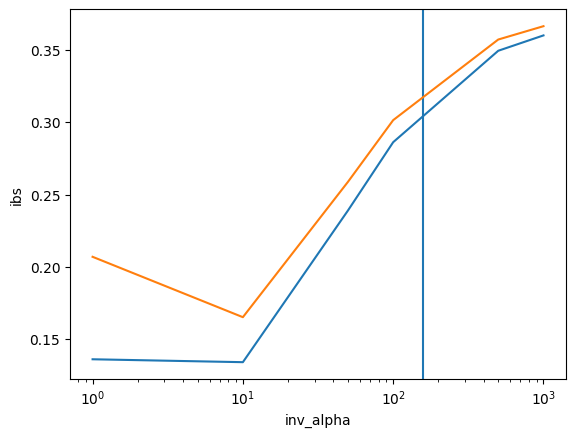

In [ ]:
plt.axvline(POW_SCALE)
sns.lineplot(df_alpha, x = 'inv_alpha', y = 'ibs').set(xscale='log')
sns.lineplot(df_alpha, x = 'inv_alpha', y = 'ibs_bal').set(xscale='log')
print(f'max_clip: {MAX_CLIP}, pow_scale: {POW_SCALE}')
